## Customer Churn Prediction

### Phase I: Dataset Loading

In [692]:
import pandas as pd

df = pd.read_csv("../data/telecom_churn.csv")

In [693]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [694]:
print("DataFrame Shape:", df.shape,"\n") # customer rows and feature columns
df.info()

DataFrame Shape: (7043, 33) 

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Inter

In [695]:
df.isnull().sum() # check missing values

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [696]:
df.describe() # only numeric columns

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [697]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].unique())


CustomerID
<StringArray>
['3668-QPYBK', '9237-HQITU', '9305-CDSKC', '7892-POOKP', '0280-XJGEX',
 '4190-MFLUW', '8779-QRDMV', '1066-JKSGK', '6467-CHFZW', '8665-UTDHZ',
 ...
 '0871-OPBXW', '3605-JISKB', '9767-FFLEM', '8456-QDAVC', '7750-EYXWZ',
 '2569-WGERO', '6840-RESVB', '2234-XADUH', '4801-JZAZL', '3186-AJIEK']
Length: 7043, dtype: str

Country
<StringArray>
['United States']
Length: 1, dtype: str

State
<StringArray>
['California']
Length: 1, dtype: str

City
<StringArray>
[    'Los Angeles',   'Beverly Hills', 'Huntington Park',         'Lynwood',
  'Marina Del Rey',       'Inglewood',    'Santa Monica',        'Torrance',
        'Whittier',        'La Habra',
 ...
      'Janesville',      'Litchfield',        'Loyalton',        'Madeline',
    'Markleeville',         'Milford',         'Calpine',        'Standish',
        'Tulelake',  'Olympic Valley']
Length: 1129, dtype: str

Lat Long
<StringArray>
['33.964131, -118.272783',  '34.059281, -118.30742', '34.048013, -118.293953',


C:\Users\darkc\AppData\Local\Temp\ipykernel_28204\1091807614.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


### Phase II: Data Cleaning

In [698]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce") # Convert Total Charges to numeric, coerce errors to NaN

In [699]:
df.isnull().sum() # check missing values

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [700]:
# Fill missing values in Total Charges

df["Total Charges"] = df["Total Charges"].fillna(
    df["Total Charges"].median()
)

In [701]:
df.isnull().sum() # check missing values

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [702]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


No duplicate records were found in the dataset

In [703]:
columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Lat Long",
    "Churn Label",
    "Churn Score",
    "Churn Reason"
]

df_clean = df.drop(columns=columns_to_drop)

In [704]:
print("DataFrame Shape:", df.shape,"\n") # customer rows and feature columns
df_clean.info()

DataFrame Shape: (7043, 33) 

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   str    
 1   Zip Code           7043 non-null   int64  
 2   Latitude           7043 non-null   float64
 3   Longitude          7043 non-null   float64
 4   Gender             7043 non-null   str    
 5   Senior Citizen     7043 non-null   str    
 6   Partner            7043 non-null   str    
 7   Dependents         7043 non-null   str    
 8   Tenure Months      7043 non-null   int64  
 9   Phone Service      7043 non-null   str    
 10  Multiple Lines     7043 non-null   str    
 11  Internet Service   7043 non-null   str    
 12  Online Security    7043 non-null   str    
 13  Online Backup      7043 non-null   str    
 14  Device Protection  7043 non-null   str    
 15  Tech Support       7043 non-null   str    
 16  Strea

### Phase III: Exploratory Data Analysis

Every visualization answers a business question

In [705]:
import matplotlib.pyplot as plt
import seaborn as sns

# Better plot aesthetics
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display all columns if needed
pd.set_option("display.max_columns", None)

### EDA 1: Target Variable Distribution
How many customers churned?

C:\Users\darkc\AppData\Local\Temp\ipykernel_28204\961850014.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Churn Value", data=df_clean, palette="Set2")
C:\Users\darkc\AppData\Local\Temp\ipykernel_28204\961850014.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No", "Yes"])


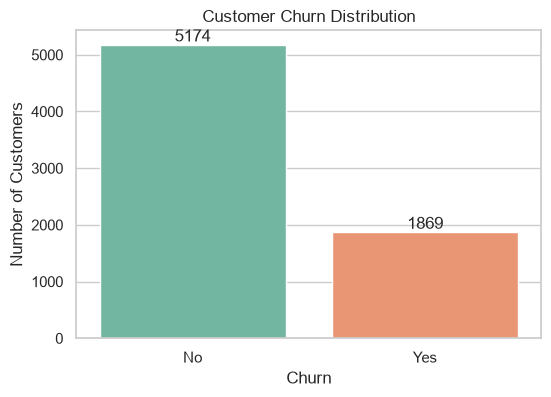

In [706]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x="Churn Value", data=df_clean, palette="Set2")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

ax.set_xticklabels(["No", "Yes"])

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom')

plt.show()

In [707]:
churn_percent = df_clean["Churn Value"].value_counts(normalize=True) * 100
print(churn_percent)

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64


Observation:

• Approximately 26.5% of customers churned, while 73.5% remained with the company.
• The dataset is moderately imbalanced.
• Customer retention is a significant business concern.

### EDA 2: Contract Type vs Churn
Which contract type has the highest churn?

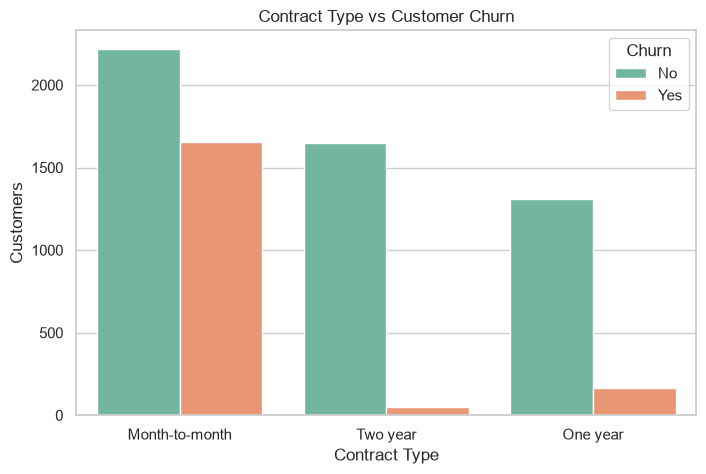

In [708]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn Value",
    data=df_clean,
    palette="Set2"
)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Customers")

plt.legend(title="Churn", labels=["No","Yes"])

plt.show()

### EDA 3: Tenure vs Churn
Does customer loyalty reduce churn?

C:\Users\darkc\AppData\Local\Temp\ipykernel_28204\1519930801.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


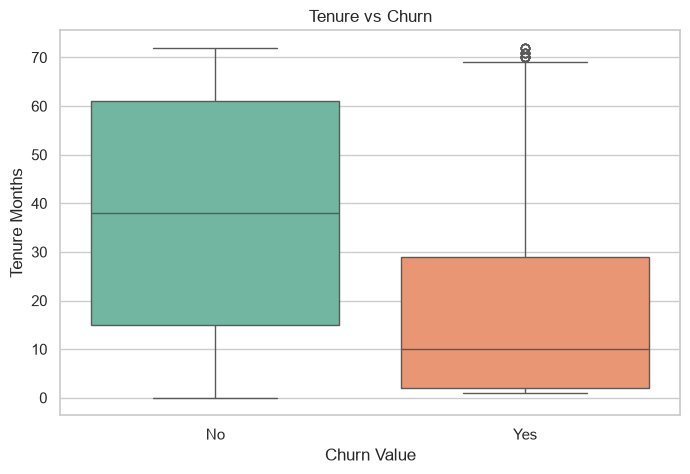

In [709]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn Value",
    y="Tenure Months",
    data=df_clean,
    palette="Set2"
)

plt.xticks([0,1],["No","Yes"])

plt.title("Tenure vs Churn")

plt.show()

### EDA 4: Monthly Charges vs Churn
Do higher bills increase churn?

C:\Users\darkc\AppData\Local\Temp\ipykernel_28204\689636117.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


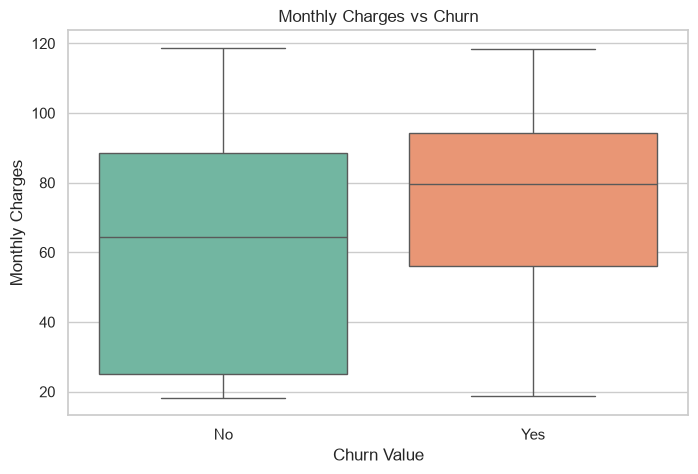

In [710]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn Value",
    y="Monthly Charges",
    data=df_clean,
    palette="Set2"
)

plt.xticks([0,1],["No","Yes"])

plt.title("Monthly Charges vs Churn")

plt.show()

### EDA 5: Internet Service vs Churn

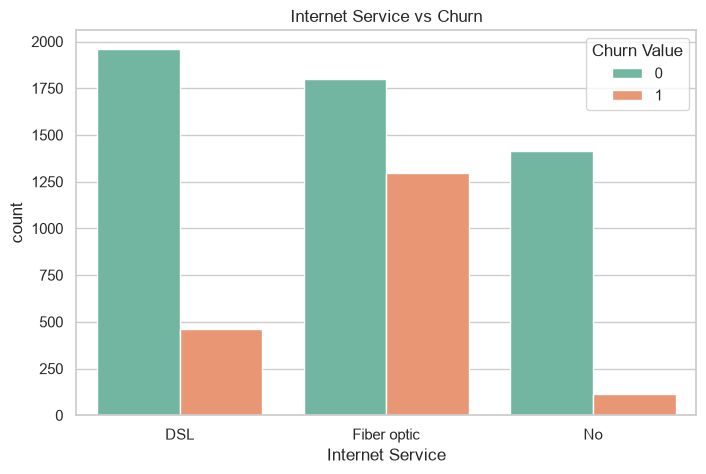

In [711]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Internet Service",
    hue="Churn Value",
    data=df_clean,
    palette="Set2"
)

plt.title("Internet Service vs Churn")

plt.show()

### EDA 6: Payment Method vs Churn

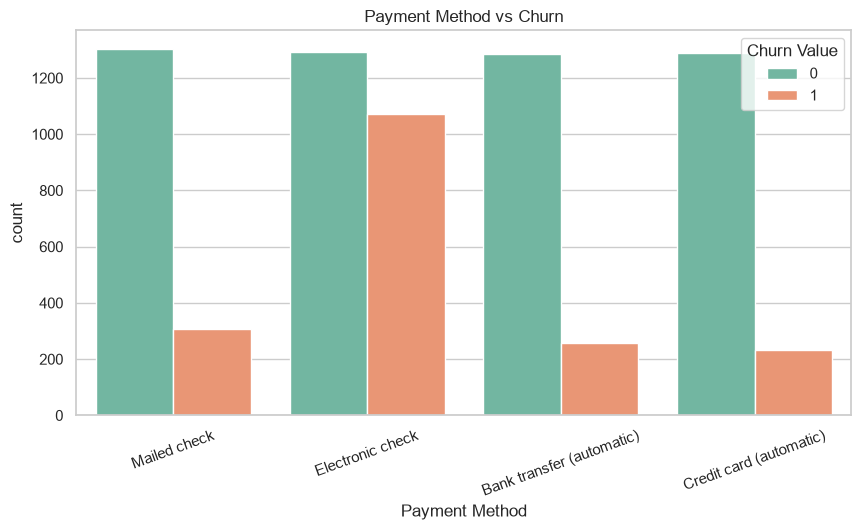

In [712]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Payment Method",
    hue="Churn Value",
    data=df_clean,
    palette="Set2"
)

plt.xticks(rotation=20)

plt.title("Payment Method vs Churn")

plt.show()

### EDA 7: Online Security vs Churn

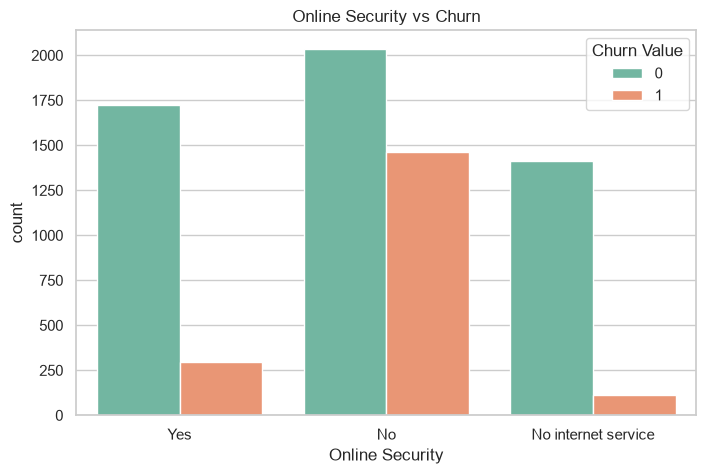

In [713]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Online Security",
    hue="Churn Value",
    data=df_clean,
    palette="Set2"
)

plt.title("Online Security vs Churn")

plt.show()

### EDA 8: Tech Support vs Churn

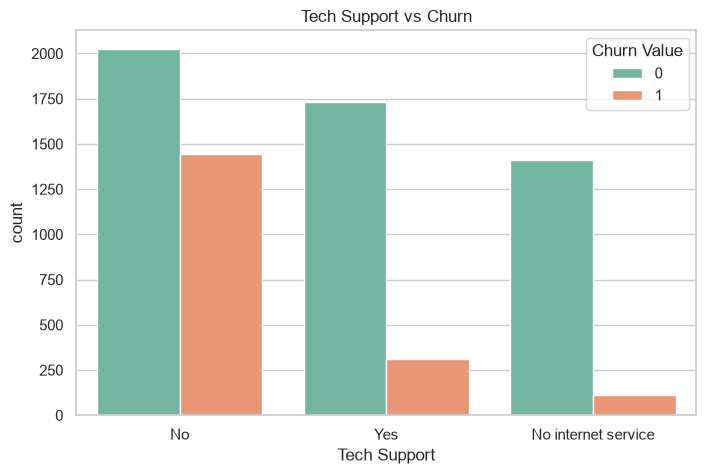

In [714]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Tech Support",
    hue="Churn Value",
    data=df_clean,
    palette="Set2"
)

plt.title("Tech Support vs Churn")

plt.show()

### EDA 9: Correlation Heatmap

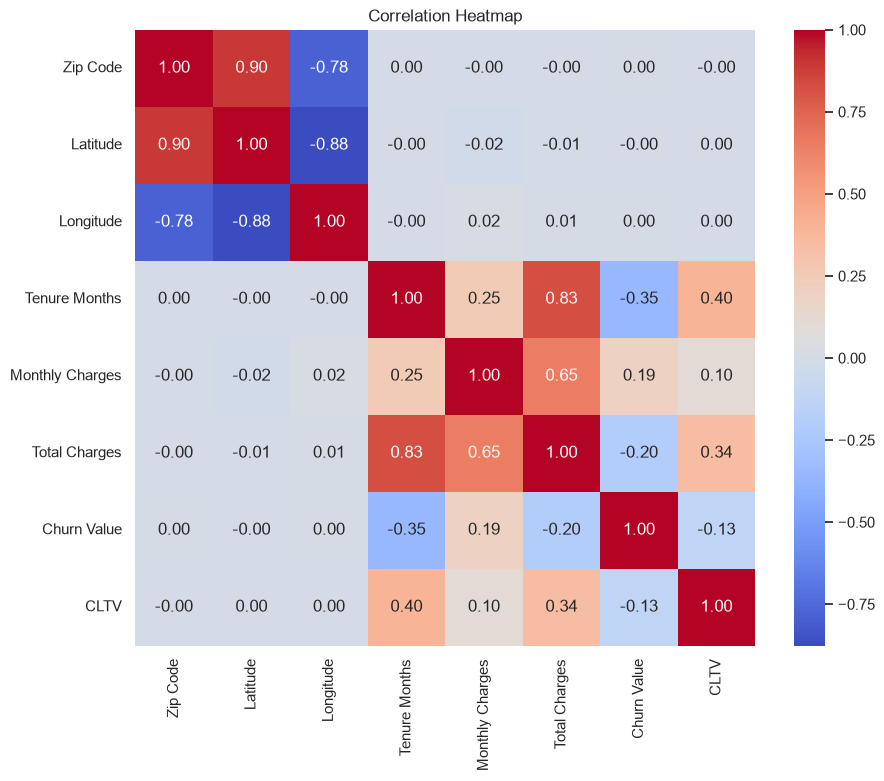

In [715]:
plt.figure(figsize=(10,8))

numeric_df = df_clean.select_dtypes(include=["int64","float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### EDA 10: Geographic Churn

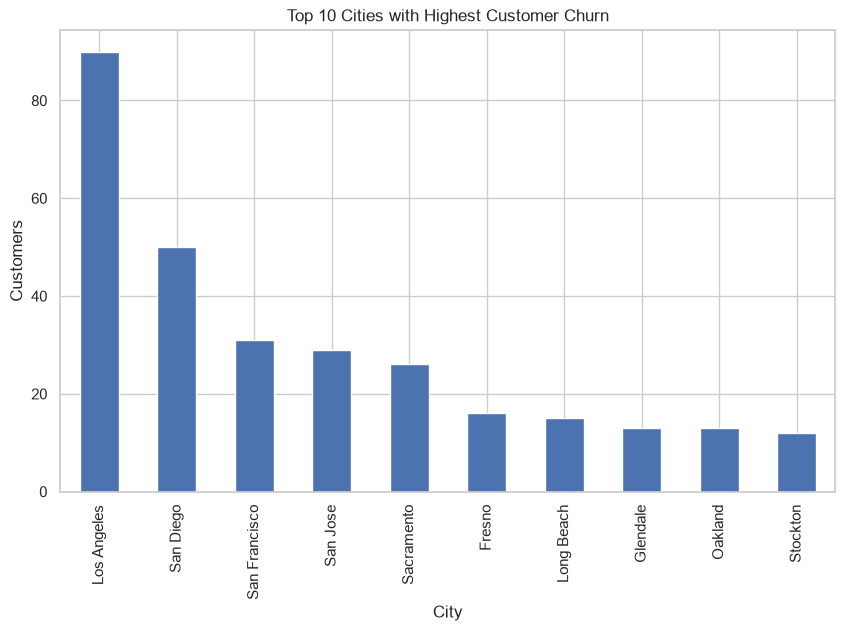

In [716]:
top_cities = (
    df_clean[df_clean["Churn Value"] == 1]
    .groupby("City")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_cities.plot(kind="bar")

plt.title("Top 10 Cities with Highest Customer Churn")
plt.ylabel("Customers")

plt.show()

These visualizations tell a clear story:

1. 26.5% of customers churned (1869 of 7043)
2. Month-to-month contracts have the highest churn by a wide margin
3. Customers with low tenure churn much more often.
4. Customers paying higher monthly charges are more likely to churn.
5. Fiber optic customers churn more than DSL or customers without internet service.
6. Electronic check users have the highest churn.
7. Customers without Online Security or Tech Support churn significantly more.
8. Tenure has the strongest negative relationship with churn among the numerical variables, while Monthly Charges show a moderate positive relationship.

### Phase IV: Feature Engineering & Preprocessing

In [717]:
X = df_clean.drop("Churn Value", axis=1)
y = df_clean["Churn Value"]

In [718]:
categorical_cols = X.select_dtypes(include=["object", "string"]).columns

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print(categorical_cols)
print(numerical_cols)

Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method'],
      dtype='str')
Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges', 'CLTV'],
      dtype='str')


In [719]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [720]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [721]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5634, 24)
(1409, 24)
Churn Value
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn Value
0    0.734564
1    0.265436
Name: proportion, dtype: float64


### Phase V: Model Building

### Model 1: Logistic Regression (Baseline)

In [722]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

In [723]:
#train
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['City','Zip Code','Latitude',...,'Monthly Charges','Total Charges','CLTV']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

In [724]:
#predict
y_pred = logistic_pipeline.predict(X_test)

y_prob = logistic_pipeline.predict_proba(X_test)[:,1]

### Model 2: Random Forest

In [725]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [726]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['City','Zip Code','Latitude',...,'Monthly Charges','Total Charges','CLTV']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

In [727]:
rf_pred = rf_pipeline.predict(X_test)

rf_prob = rf_pipeline.predict_proba(X_test)[:,1]

### Model 3: XGBoost

In [728]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [729]:
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['City','Zip Code','Latitude',...,'Monthly Charges','Total Charges','CLTV']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

In [730]:
xgb_pred = xgb_pipeline.predict(X_test)

xgb_prob = xgb_pipeline.predict_proba(X_test)[:,1]

### Phase VI: Model Evaluation

In [731]:
# Import Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

In [732]:
# Evaluation Function

def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

### Evaluate Logistic Regression

Logistic Regression
Accuracy : 0.7913
Precision: 0.6198
Recall   : 0.5535
F1 Score : 0.5847
ROC-AUC  : 0.8403

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.78      0.79      0.79      1409



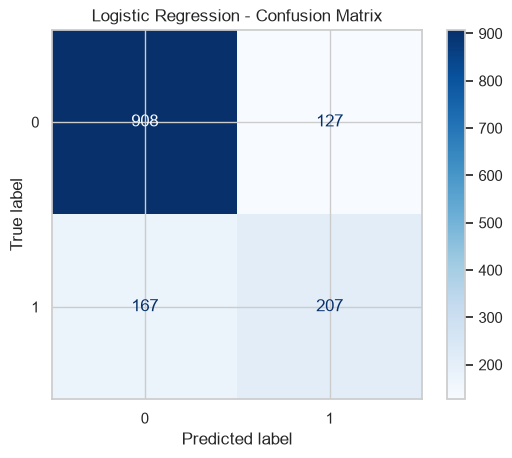

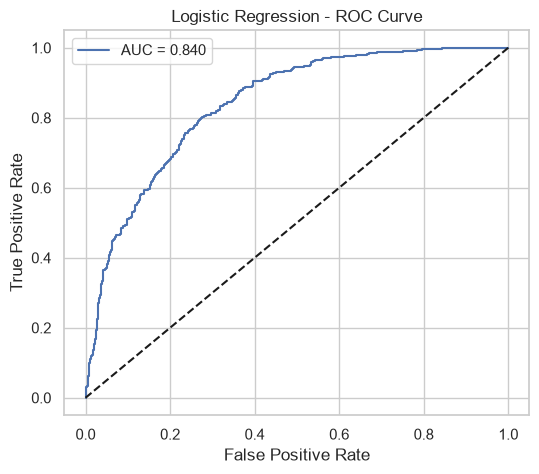

In [733]:
lr_results = evaluate_model(
    logistic_pipeline,
    X_test,
    y_test,
    "Logistic Regression"
)

### Evaluate Random Forest

Random Forest
Accuracy : 0.7956
Precision: 0.6514
Recall   : 0.4947
F1 Score : 0.5623
ROC-AUC  : 0.8415

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.49      0.56       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.80      0.79      1409



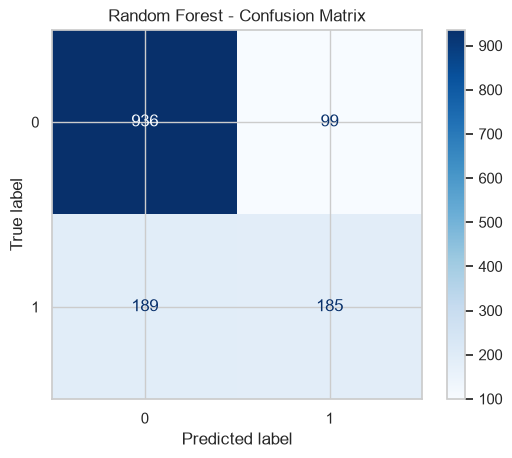

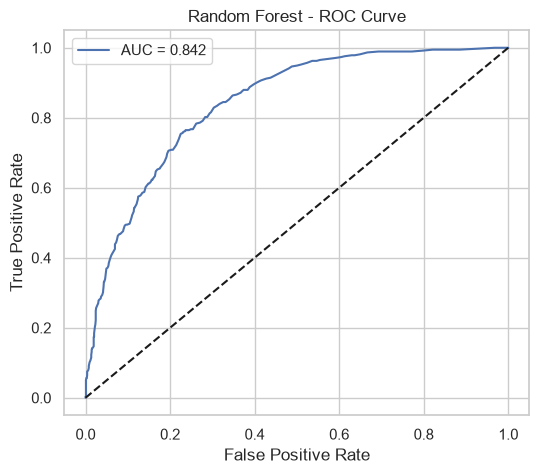

In [734]:
rf_results = evaluate_model(
    rf_pipeline,
    X_test,
    y_test,
    "Random Forest"
)

### Evaluate XGBoost

XGBoost
Accuracy : 0.7921
Precision: 0.6254
Recall   : 0.5401
F1 Score : 0.5796
ROC-AUC  : 0.8343

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



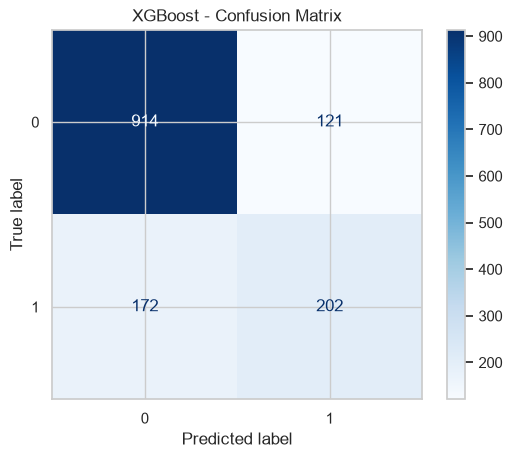

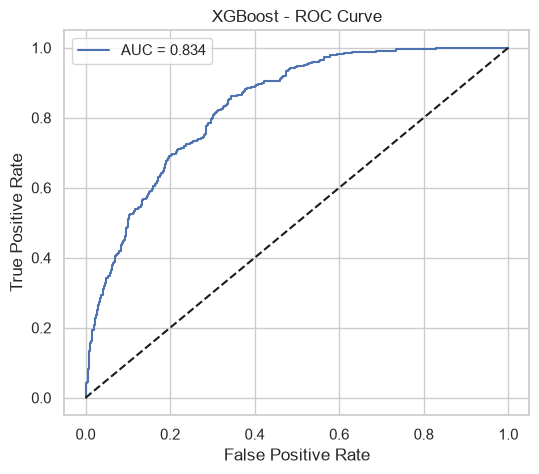

In [735]:
xgb_results = evaluate_model(
    xgb_pipeline,
    X_test,
    y_test,
    "XGBoost"
)

### Phase VII: Model Comparison

In [736]:
comparison_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results
])

comparison_df = comparison_df.round(4)

comparison_df = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.7956,0.6514,0.4947,0.5623,0.8415
0,Logistic Regression,0.7913,0.6198,0.5535,0.5847,0.8403
2,XGBoost,0.7921,0.6254,0.5401,0.5796,0.8343


## Model Comparison

Three machine learning algorithms were evaluated using Accuracy,
Precision, Recall, F1 Score, and ROC-AUC.

The best-performing model was selected based on its overall
predictive performance, particularly ROC-AUC and F1 Score, since
customer churn prediction is a classification problem with
moderate class imbalance.

### Phase VIII: Feature Importance & Model Saving

In [737]:
# Select the best model
best_model = rf_pipeline

# Get feature names
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Get importance scores
importance = best_model.named_steps["model"].feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
3,num__Tenure Months,0.072099
5,num__Total Charges,0.070955
4,num__Monthly Charges,0.057262
6,num__CLTV,0.048878
1,num__Latitude,0.046548
0,num__Zip Code,0.046530
2,num__Longitude,0.045868
1169,cat__Contract_Month-to-month,0.031876
1176,cat__Payment Method_Electronic check,0.021544
1151,cat__Online Security_No,0.020653


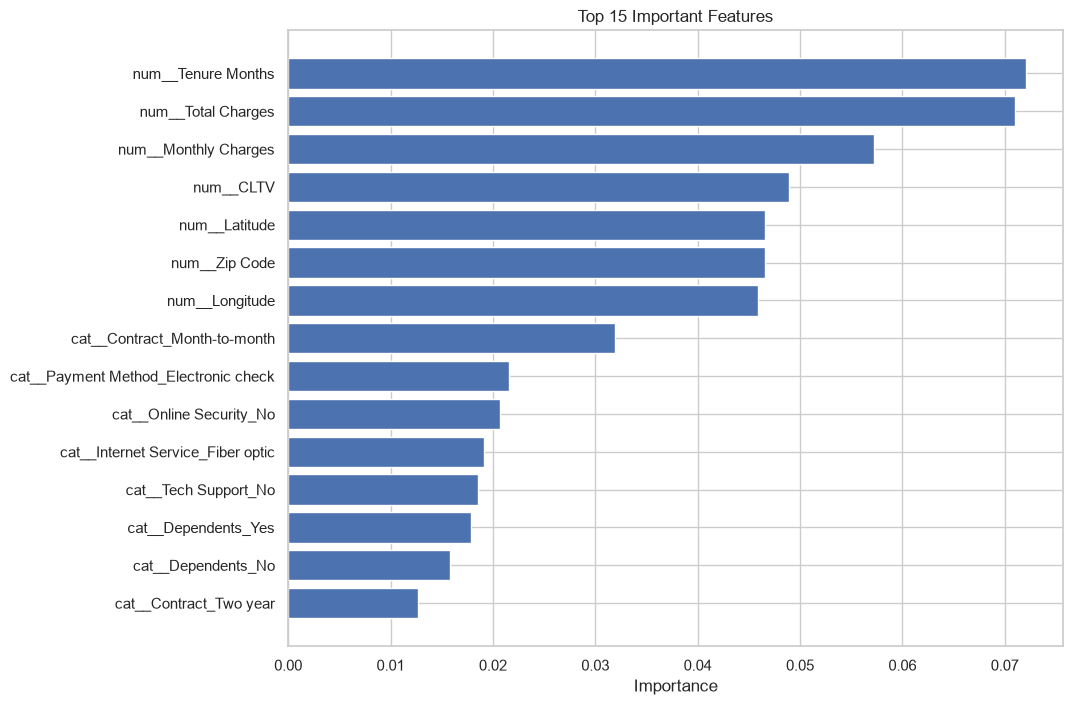

In [738]:
# Plot Top 15 Features

plt.figure(figsize=(10,8))

top15 = importance_df.head(15)

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")
plt.xlabel("Importance")

plt.show()

In [739]:
import joblib

joblib.dump(
    best_model,
    "../models/churn_prediction_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


### Phase IX: Business Recommendations

Based on exploratory data analysis and machine learning results, the following recommendations are proposed:

1. Encourage customers to switch from Month-to-Month contracts to One-Year or Two-Year plans through discounts and loyalty programs.

2. Focus customer retention campaigns on customers with lower tenure since they are more likely to churn.

3. Promote Online Security and Tech Support services to customers without these services.

4. Review pricing strategies for customers with higher monthly charges.

5. Improve the customer experience of Fiber Optic services.

6. Deploy the trained machine learning model to identify high-risk customers and proactively offer personalized retention incentives.

### Future Improvements

• Hyperparameter tuning using RandomizedSearchCV or GridSearchCV\
• Cross-validation for improved model robustness\
• Deployment using Streamlit or Flask\
• Real-time churn prediction dashboard

### Phase X: Conclusion

This project developed an end-to-end customer churn prediction system using machine learning.

Three classification algorithms - Logistic Regression, Random Forest, and XGBoost - were trained and evaluated. Among them, Random Forest achieved the best overall predictive performance with an Accuracy of 79.56% and a ROC-AUC score of 84.15%.

Feature importance analysis showed that Tenure Months, Total Charges, Monthly Charges, Contract Type, Payment Method, Online Security, and Tech Support were among the most influential predictors of customer churn.

The developed model can assist telecom companies in identifying customers who are likely to churn and support data-driven retention strategies to improve customer satisfaction and reduce revenue loss.